# Setup and Context

<img src="https://i.imgur.com/gugIA5r.png" width=700>

### Introduction

Dr Ignaz Semmelweis was a Hungarian physician born in 1818 who worked in the Vienna General Hospital. In the past people thought of illness as caused by "bad air" or evil spirits. But in the 1800s Doctors started looking more at anatomy, doing autopsies and started making arguments based on data. Dr Semmelweis suspected that something was going wrong with the procedures at Vienna General Hospital. Semmelweis wanted to figure out why so many women in maternity wards were dying from childbed fever (i.e., [puerperal fever](https://en.wikipedia.org/wiki/Postpartum_infections)).

<img src=https://i.imgur.com/lSyNUwR.png width=700>

Today you will become Dr Semmelweis. This is your office 👆. You will step into Dr Semmelweis' shoes and analyse the same data collected from 1841 to 1849.

### The Data Source

Dr Semmelweis published his research in 1861. I found the scanned pages of the [full text with the original tables in German](http://www.deutschestextarchiv.de/book/show/semmelweis_kindbettfieber_1861), but an excellent [English translation can be found here](http://graphics8.nytimes.com/images/blogs/freakonomics/pdf/the%20etiology,%20concept%20and%20prophylaxis%20of%20childbed%20fever.pdf).

<img src=https://i.imgur.com/6HfLtaC.png width=500>

### Upgrade plotly (only Google Colab Notebook)

Google Colab may not be running the latest version of plotly. If you're working in Google Colab, uncomment the line below, run the cell, and restart your notebook server.

In [1]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 103.5 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


### Import Statements

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats

### Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

# Create locators for ticks on the time axis
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()



In [46]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


### Read the Data

In [5]:
df_yearly = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/annual_deaths_by_clinic.csv')

# parse_dates avoids DateTime conversion later
df_monthly = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/monthly_deaths.csv',
                      parse_dates=['date'])

# Preliminary Data Exploration

**Challenge**: Check out these two DataFrames ☝️.
* What is the shape of df_yearly and df_monthly? How many rows and columns?
* What are the column names?
* Which years are included in the dataset?
* Are there any NaN values or duplicates?
* What were the average number of births that took place per month?
* What were the average number of deaths that took place per month?

In [6]:
# What is the shape of df_yearly ?
# How many rows and columns?
# What are the column names
df_yearly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    12 non-null     int64 
 1   births  12 non-null     int64 
 2   deaths  12 non-null     int64 
 3   clinic  12 non-null     object
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes


In [7]:
# Which years are included in the dataset?  (1841 - 1846)
# 6 years for Clinic 1
# 6 years for Clinic 2
print(df_yearly.shape)
df_yearly

(12, 4)


,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [8]:
# Which years are included in the dataset?  (1841 - 1846)
# 6 years for Clinic 1 (1841 - 1846)
# 6 years for Clinic 2 (1841 - 1846)
print(df_yearly.shape)
df_yearly

(12, 4)


,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [43]:
# What is the shape of df_monthly ?
# How many rows and columns?
# What are the column names
print(df_monthly.shape)
df_monthly.head(), df_monthly.tail()

(98, 5)


(        date  births  deaths  pct_deaths washing_hands
 0 1841-01-01     254      37       14.57            No
 1 1841-02-01     239      18        7.53            No
 2 1841-03-01     277      12        4.33            No
 3 1841-04-01     255       4        1.57            No
 4 1841-05-01     255       2        0.78            No,
          date  births  deaths  pct_deaths washing_hands
 93 1848-11-01     310       9        2.90           Yes
 94 1848-12-01     373       5        1.34           Yes
 95 1849-01-01     403       9        2.23           Yes
 96 1849-02-01     389      12        3.08           Yes
 97 1849-03-01     406      20        4.93           Yes)

In [10]:
# What is the shape of df_monthly ?
# How many rows and columns?
# What are the column names & types
df_monthly.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    98 non-null     datetime64[ns]
 1   births  98 non-null     int64         
 2   deaths  98 non-null     int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 2.4 KB


In [11]:
# Which years are included in the dataset?  (date 1841 -1849)
df_monthly.describe()

,date,births,deaths
count,98,98.00,98.00
mean,1845-02-11 04:24:29.387755008,267.00,22.47
min,1841-01-01 00:00:00,190.00,0.00
25%,1843-02-08 00:00:00,242.50,8.00
50%,1845-02-15 00:00:00,264.00,16.50
75%,1847-02-22 00:00:00,292.75,36.75
max,1849-03-01 00:00:00,406.00,75.00
std,NaN,41.77,18.14


In [12]:
# Which years are included in the dataset? (1841 -1849)
df_monthly.head(), df_monthly.tail()

(        date  births  deaths
 0 1841-01-01     254      37
 1 1841-02-01     239      18
 2 1841-03-01     277      12
 3 1841-04-01     255       4
 4 1841-05-01     255       2,
          date  births  deaths
 93 1848-11-01     310       9
 94 1848-12-01     373       5
 95 1849-01-01     403       9
 96 1849-02-01     389      12
 97 1849-03-01     406      20)

### Check for Nan Values and Duplicates

In [13]:
# NaN Value Check
print(f'NaN values in df_yearly dataset ? {df_yearly.isna().values.any()}')
print(f'NaN values in df_monthly dataset ? {df_monthly.isna().values.any()}')


NaN values in df_yearly dataset ? False
NaN values in df_monthly dataset ? False


In [14]:
# Duplicates Check
print(f'Duplicates in df_yearly dataset ? ? {df_yearly.duplicated().values.any()}')
print(f'Duplicates in df_monthly dataset ? ? {df_monthly.duplicated().values.any()}')

Duplicates in df_yearly dataset ? ? False
Duplicates in df_monthly dataset ? ? False


### Descriptive Statistics

In [15]:
# Yearly Descriptive Statistics
df_yearly.describe()

,year,births,deaths
count,12.00,12.00,12.00
mean,"1,843.50","3,152.75",223.33
std,1.78,449.08,145.38
min,"1,841.00","2,442.00",66.00
25%,"1,842.00","2,901.75",100.25
50%,"1,843.50","3,108.50",219.50
75%,"1,845.00","3,338.25",263.50
max,"1,846.00","4,010.00",518.00


In [16]:
# Monthly Descriptive Statistics
# We see that on average there were about 267 births and 22.47 deaths per month.
df_monthly.describe()

,date,births,deaths
count,98,98.00,98.00
mean,1845-02-11 04:24:29.387755008,267.00,22.47
min,1841-01-01 00:00:00,190.00,0.00
25%,1843-02-08 00:00:00,242.50,8.00
50%,1845-02-15 00:00:00,264.00,16.50
75%,1847-02-22 00:00:00,292.75,36.75
max,1849-03-01 00:00:00,406.00,75.00
std,NaN,41.77,18.14


### Percentage of Women Dying in Childbirth

**Challenge**: How dangerous was childbirth in the 1840s in Vienna?

* Using the annual data, calculate the percentage of women giving birth who died throughout the 1840s at the hospital.


In comparison, the United States recorded 18.5 maternal deaths per 100,000 or 0.018% in 2013 [(source).](
https://en.wikipedia.org/wiki/Maternal_death#:~:text=The%20US%20has%20the%20%22highest,17.8%20per%20100%2C000%20in%202009)

In [17]:
# Calculate the percentage of women giving birth who died throughout the 1840s
prob = df_yearly.deaths.sum() / df_yearly.births.sum() * 100
print(f'Chances of dying in the 1840s in Vienna: {prob:.3}%')

Chances of dying in the 1840s in Vienna: 7.08%


# Visualise the Total Number of Births 🤱 and Deaths 💀 over Time

### Plot the Monthly Data on Twin Axes

**Challenge**: Create a [Matplotlib chart](https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.plot.html) with twin y-axes. It should look something like this:

<img src=https://i.imgur.com/F9DOJxx.png width=700>

* Format the x-axis using locators for the years and months (Hint: we did this in the Google Trends notebook)
* Set the range on the x-axis so that the chart lines touch the y-axes
* Add gridlines
* Use `skyblue` and `crimson` for the line colours
* Use a dashed line style for the number of deaths
* Change the line thickness to 3 and 2 for the births and deaths respectively.
* Do you notice anything in the late 1840s?

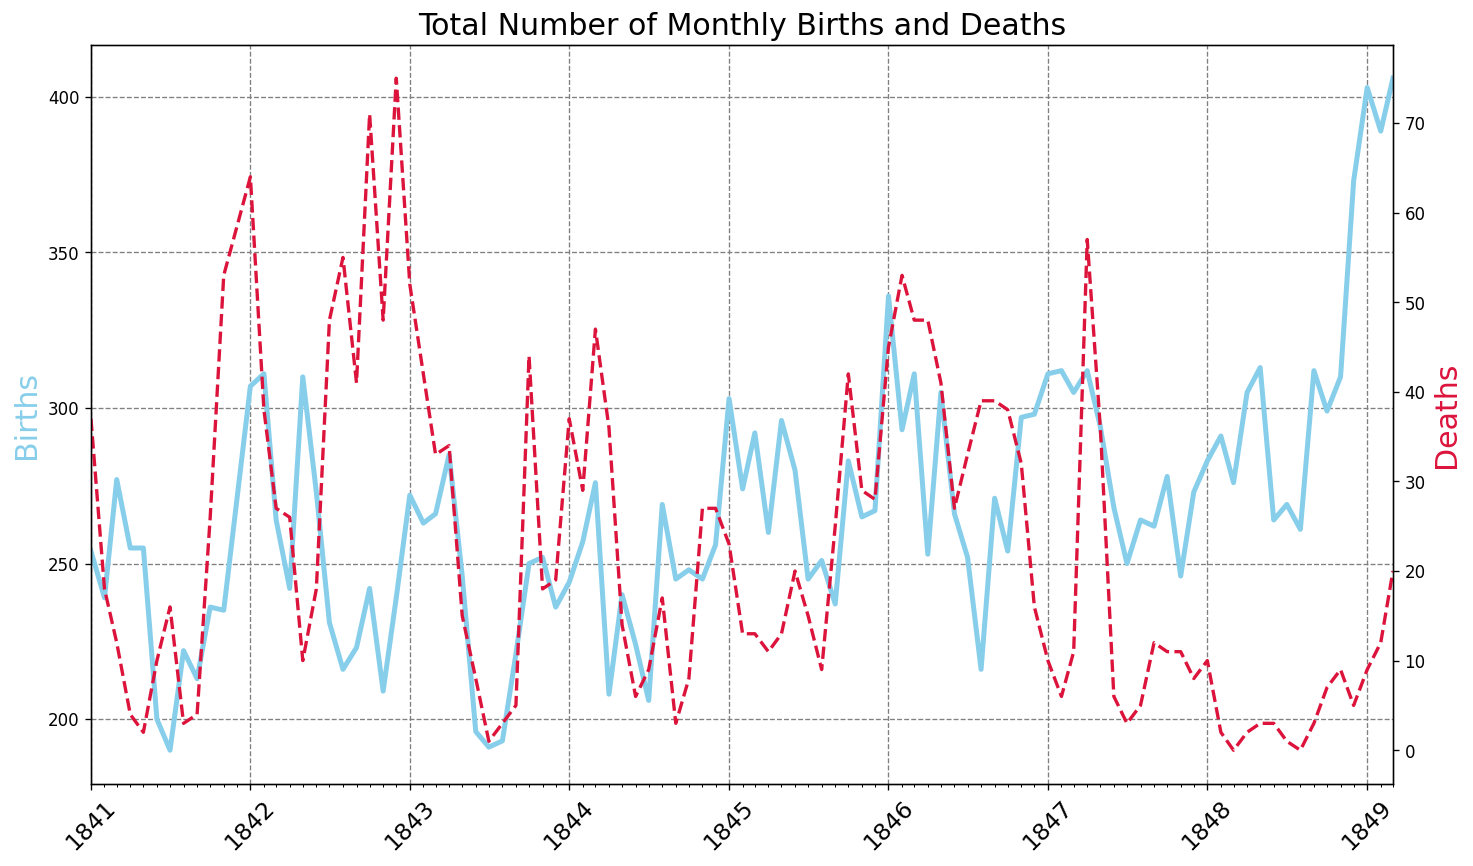

In [18]:
# Plot the Monthly Data on Twin Axes (Matplotlib)

# Create locators for ticks on the time axis
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

# Increase the size and rotate the labels on the x-axis
plt.figure(figsize=(14,8), dpi=120)
plt.title(f'Total Number of Monthly Births and Deaths', fontsize=18)
plt.xticks(fontsize=14, rotation=45)

ax1 = plt.gca()
ax2 = ax1.twinx()

# Set Labelling
ax1.set_ylabel('Births', color='skyblue', fontsize=18)
ax2.set_ylabel('Deaths', color='crimson', fontsize=18)

# Use Locators for X-Axis Time Series Formatting
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_minor_locator(months)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.set_xlim([df_monthly.date.min(), df_monthly.date.max()])

# Show the grid lines as dark grey lines
ax1.grid(color='grey', linestyle='--')

# Plot chart with the linestyle and markers
ax1.plot(df_monthly.date,
         df_monthly.births,
         color='skyblue',
         linewidth=3)

ax2.plot(df_monthly.date,
         df_monthly.deaths,
         color='crimson',
         linewidth=2,
         linestyle='--')


# Displays chart explicity
plt.show()

**What do we see**
Something happened after 1847.

The total number of deaths have dropped, despite an increasing number of births!

# The Yearly Data Split by Clinic

Now let's look at the annual data instead.

**Challenge**: Use plotly to create line charts of the births and deaths of the two different clinics at the Vienna General Hospital.
* Which clinic is bigger or more busy judging by the number of births?
* Has the hospital had more patients over time?
* What was the highest number of deaths recorded in clinic 1 and clinic 2?

In [44]:
# create line charts of the births and deaths of the two different clinics at the Vienna General Hospital.
line = px.line(df_yearly,
               x='year',
               y='births',
               color='clinic',
               title='Total Yearly Births by Clinic')

line.show()

In [20]:
# create line charts of the deaths of the two different clinics at the Vienna General Hospital.
line = px.line(df_yearly,
               x='year',
               y='deaths',
               color='clinic',
               title='Total Yearly Deaths by Clinic')

line.show()

**What do we see**

More women gave birth at the hospital over the years.

Clinic 1, which was staffed by male doctors and medical students was also the
busier or simply had larger wards.

More births took place in clinic 1 than in clinic 2.

Not only were more people born in clinic 1, more people also died in clinic 1.

1842 was a rough year.<br>
About 16% of women died in clinic 1 and about 7.6% of women died in clinic 2.

### Calculate the Proportion of Deaths at Each Clinic

**Challenge**: Calculate the proportion of maternal deaths per clinic. That way we can compare like with like.
* Work out the percentage of deaths for each row in the `df_yearly` DataFrame by adding a column called "pct_deaths".
* Calculate the average maternal death rate for clinic 1 and clinic 2 (i.e., the total number of deaths per the total number of births).
* Create another plotly line chart to see how the percentage varies year over year with the two different clinics.
* Which clinic has a higher proportion of deaths?
* What is the highest monthly death rate in clinic 1 compared to clinic 2?

In [21]:
# Add a column to df_yearly called "pct_deaths" showing the percentage of deaths
df_yearly['pct_deaths'] = df_yearly.deaths / df_yearly.births
df_yearly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        12 non-null     int64  
 1   births      12 non-null     int64  
 2   deaths      12 non-null     int64  
 3   clinic      12 non-null     object 
 4   pct_deaths  12 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 612.0+ bytes


In [45]:
df_yearly.head()

,year,births,deaths,clinic,pct_deaths
0,1841,3036,237,clinic 1,0.08
1,1842,3287,518,clinic 1,0.16
2,1843,3060,274,clinic 1,0.09
3,1844,3157,260,clinic 1,0.08
4,1845,3492,241,clinic 1,0.07


In [23]:
# Calculate the average maternal death rate for clinic 1
clinic_1 = df_yearly[df_yearly.clinic == 'clinic 1']
avg_c1 = clinic_1.deaths.sum() / clinic_1.births.sum() * 100

print(f'Average death rate in clinic 1 is {avg_c1:.3}%.')

Average death rate in clinic 1 is 9.92%.


In [24]:
# Calculate the average maternal death rate for clinic 2
clinic_2 = df_yearly[df_yearly.clinic == 'clinic 2']
avg_c2 = clinic_2.deaths.sum() / clinic_2.births.sum() * 100
print(f'Average death rate in clinic 2 is {avg_c2:.3}%.')

Average death rate in clinic 2 is 3.88%.


**What do we see**

Clinic 2 which was staffed by midwives had a much lower death rate of 3.88% over the course of the entire period.

Hmm... 🤔

### Plotting the Proportion of Yearly Deaths by Clinic

In [25]:
# Plotting the Proportion of Yearly Deaths for Clinic 1 (Plotly)
line = px.line(clinic_1,
               x='year',
               y='deaths',
               color='clinic',
               title='Total Yearly Deaths for Clinic 1')

line.show()

In [26]:
# Plotting the Proportion of Yearly Deaths for Clinic 2 (Plotly)
line = px.line(clinic_2,
               x='year',
               y='deaths',
               color='clinic',
               title='Total Yearly Deaths for Clinic 2')

line.show()

# The Effect of Handwashing

Dr Semmelweis made handwashing obligatory in the summer of 1947. In fact, he ordered people to wash their hands with clorine (instead of water).

In [27]:
# Date when handwashing was made mandatory
handwashing_start = pd.to_datetime('1847-06-01')
type(handwashing_start)

pandas._libs.tslibs.timestamps.Timestamp

**Challenge**:
* Add a column called "pct_deaths" to `df_monthly` that has the percentage of deaths per birth for each row.
* Create two subsets from the `df_monthly` data: before and after Dr Semmelweis ordered washing hand.
* Calculate the average death rate prior to June 1947.
* Calculate the average death rate after June 1947.

In [28]:
# Add a column called "pct_deaths" to df_monthly that has the percentage of deaths per birth for each row.
df_monthly['pct_deaths'] = df_monthly.deaths / df_monthly.births * 100
df_monthly.sample(5)

,date,births,deaths,pct_deaths
37,1844-03-01,276,47,17.03
53,1845-07-01,245,15,6.12
76,1847-06-01,268,6,2.24
77,1847-07-01,250,3,1.20
20,1842-10-01,242,71,29.34


In [29]:
df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        98 non-null     datetime64[ns]
 1   births      98 non-null     int64         
 2   deaths      98 non-null     int64         
 3   pct_deaths  98 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 3.2 KB


In [30]:
# Create two subsets from the df_monthly data: before and after Dr Semmelweis ordered washing hand.

# Date when handwashing was made mandatory
handwashing_start = pd.to_datetime('1847-06-01')

# Calculate the average death rate BEFORE June 1846.
before_washing = df_monthly[df_monthly.date < handwashing_start]

# Calculate the average death rate AFTER June 1846.
after_washing  = df_monthly[df_monthly.date > handwashing_start]

bw_rate = before_washing.deaths.sum() / before_washing.births.sum() * 100
aw_rate = after_washing.deaths.sum() / after_washing.births.sum() * 100
print(f'Average death rate BEFORE 1847 was {bw_rate:.4}%')
print(f'Average death rate AFTER 1847 was {aw_rate:.3}%')


Average death rate BEFORE 1847 was 10.53%
Average death rate AFTER 1847 was 2.15%


### Calculate a Rolling Average of the Death Rate


Moving averages (MAs) are used to analyze data by smoothing out short-term fluctuations ("noise") to reveal longer-term trends, cycles, or direction.

They act as dynamic support and resistance levels, provide buy/sell signals, and assist in gauging market momentum or general sentiment.

They are common in financial charting and time-series data Analysis

**Challenge**: Create a DataFrame that has the 6 month rolling average death rate prior to mandatory handwashing.

*Hint*: You'll need to set the dates as the index in order to avoid the date column being dropped during the calculation.

In [47]:
# Create a DataFrame that has the 6 month rolling average death rate prior to mandatory handwashing.
roll_df = before_washing.set_index('date')
roll_df = roll_df.rolling(window=6).mean()

### Highlighting Subsections of a Line Chart

**Challenge**: Copy-paste and then modify the Matplotlib chart from before to plot the monthly death rates (instead of the total number of births and deaths). The chart should look something like this:

<img src=https://i.imgur.com/X6TQe0R.png width=500>

* Add 3 seperate lines to the plot: the death rate before handwashing, after handwashing, and the 6-month moving average before handwashing.
* Show the monthly death rate before handwashing as a thin dashed black line.
* Show the moving average as a thicker, crimon line.
* Show the rate after handwashing as a skyblue line with round markers.
* Look at the [code snippet in the documentation to see how you can add a legend](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.legend.html) to the chart.

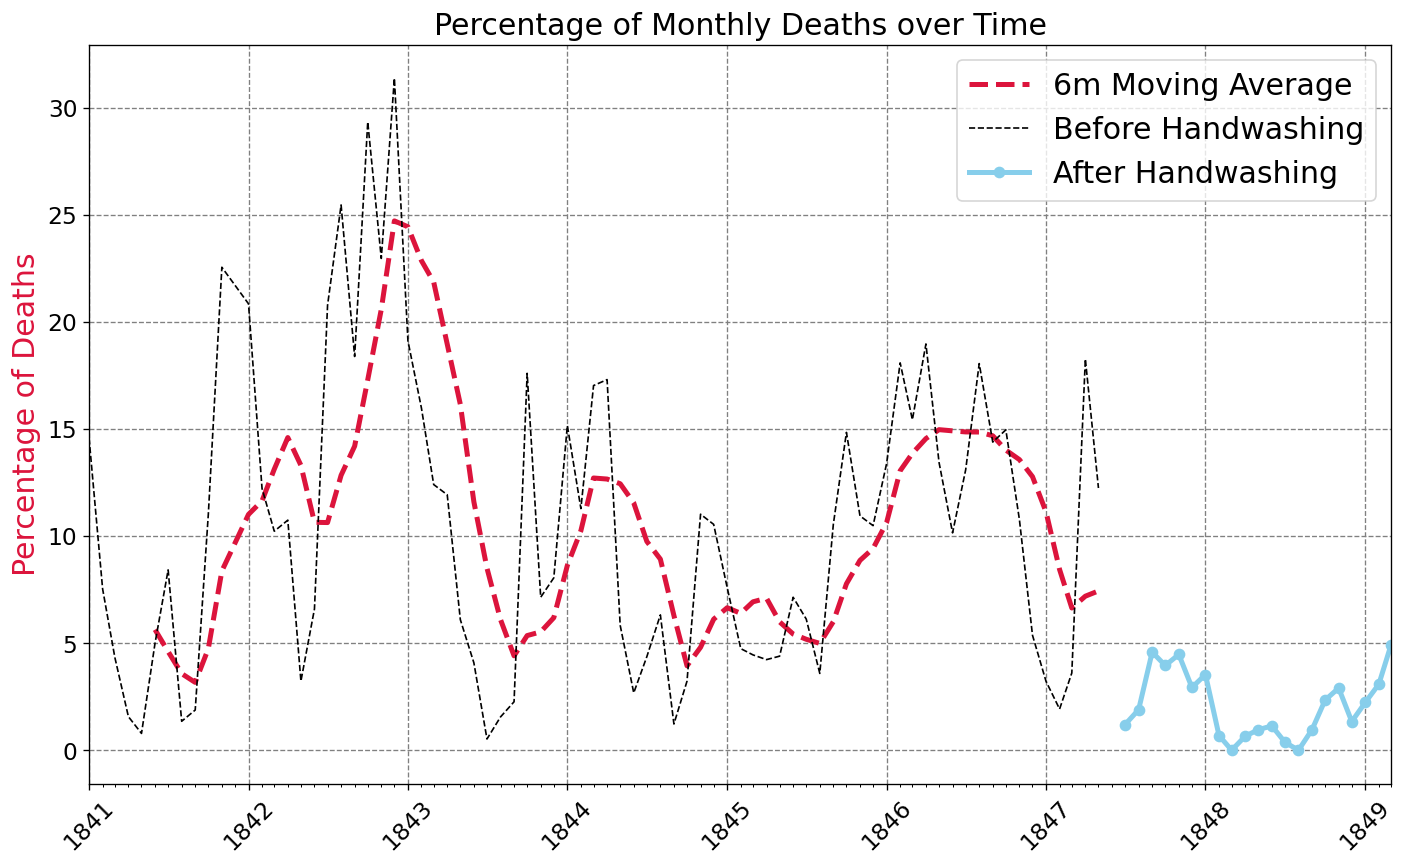

In [32]:
# Plot the monthly death rates (MatPlotLib)

# Labels - increase the size and rotate the labels on the x-axis
plt.figure(figsize=(14,8), dpi=120)
plt.title(f'Percentage of Monthly Deaths over Time', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

plt.ylabel('Percentage of Deaths', color='crimson', fontsize=18)

# Use Locators  (X Axis TimeSeries Formatting)
ax = plt.gca()

ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.xaxis.set_minor_locator(months)
ax.set_xlim([df_monthly.date.min(), df_monthly.date.max()])

# Show the grid lines as dark grey lines
plt.grid(color='grey', linestyle='--')


# Plot chart with the linestyle and markers (incl legend handles - ma_line ...)
ma_line, = plt.plot(roll_df.index,
                    roll_df.pct_deaths,
                    color='crimson',
                    linewidth=3,
                    linestyle='--',
                    label='6m Moving Average')
bw_line, = plt.plot(before_washing.date,
                    before_washing.pct_deaths,
                    color='black',
                    linewidth=1,
                    linestyle='--',
                    label='Before Handwashing')
aw_line, = plt.plot(after_washing.date,
                    after_washing.pct_deaths,
                    color='skyblue',
                    linewidth=3,
                    marker='o',
                    label='After Handwashing')

plt.legend(handles=[ma_line, bw_line, aw_line],
           fontsize=18)

# Displays chart explicity
plt.show()

### Statistics - Calculate the Difference in the Average Monthly Death Rate

**Challenge**:
* What was the average percentage of monthly deaths before handwashing?
* What was the average percentage of monthly deaths after handwashing was made obligatory?
* By how much did handwashing reduce the average chance of dying in childbirth in percentage terms?
* How do these numbers compare to the average for all the 1840s that we calculated earlier?
* How many times lower are the chances of dying after handwashing compared to before?

In [33]:
# What was the average percentage of monthly deaths before handwashing?
avg_prob_before = before_washing.pct_deaths.mean()
print(f'Chance of death during childbirth before handwashing: {avg_prob_before:.3}%.')

# What was the average percentage of monthly deaths after handwashing was made obligatory?
avg_prob_after = after_washing.pct_deaths.mean()
print(f'Chance of death during childbirth AFTER handwashing: {avg_prob_after:.3}%.')

# How much did handwashing reduce the average chance of dying in childbirth in percentage terms?
mean_diff = avg_prob_before - avg_prob_after
print(f'Handwashing reduced the monthly proportion of deaths by {mean_diff:.3}%!')

# How do these numbers compare to the average for all the 1840s?
times = avg_prob_before / avg_prob_after
print(f'This is a {times:.2}x improvement!')

Chance of death during childbirth before handwashing: 10.5%.
Chance of death during childbirth AFTER handwashing: 2.1%.
Handwashing reduced the monthly proportion of deaths by 8.4%!
This is a 5.0x improvement!


### Use Box Plots to Show How the Death Rate Changed Before and After Handwashing

**Challenge**:
* Use [NumPy's `.where()` function](https://numpy.org/doc/stable/reference/generated/numpy.where.html) to add a column to `df_monthly` that shows if a particular date was before or after the start of handwashing.
* Then use plotly to create box plot of the data before and after handwashing.
* How did key statistics like the mean, max, min, 1st and 3rd quartile changed as a result of the new policy?



In [34]:
# Add a column to df_monthly that shows if a date was before or after handwashing.
df_monthly['washing_hands'] = np.where(df_monthly.date < handwashing_start, 'No', 'Yes')
df_monthly.sample(5)


,date,births,deaths,pct_deaths,washing_hands
12,1842-02-01,311,38,12.22,No
2,1841-03-01,277,12,4.33,No
77,1847-07-01,250,3,1.20,Yes
15,1842-05-01,310,10,3.23,No
75,1847-05-01,294,36,12.24,No


In [35]:
# Use plotly to create box plot of the data before and after handwashing.
box = px.box(df_monthly,
             x='washing_hands',
             y='pct_deaths',
             color='washing_hands',
             title='How Have the Stats Changed with Handwashing?')

box.update_layout(xaxis_title='Washing Hands?',
                  yaxis_title='Percentage of Monthly Deaths',)

box.add_annotation(
    x=0.0, y=31,
    text="Over 30% in 1842",
    showarrow=True,
    arrowhead=2,
    yshift=10                  # Moves text up slightly
)


box.show()

### Use Histograms to Visualise the Monthly Distribution of Outcomes

**Challenge**: Create a [plotly histogram](https://plotly.com/python/histograms/) to show the monthly percentage of deaths.

* Use docs to check out the available parameters. Use the [`color` parameter](https://plotly.github.io/plotly.py-docs/generated/plotly.express.histogram.html) to display two overlapping histograms.
* The time period of handwashing is shorter than not handwashing. Change `histnorm` to `percent` to make the time periods comparable.
* Make the histograms slighlty transparent
* Experiment with the number of bins on the histogram. Which number work well in communicating the range of outcomes?
* Just for fun, display your box plot on the top of the histogram using the `marginal` parameter.

In [36]:
# Use Histograms to Visualise the Monthly Distribution of Outcomes

hist = px.histogram(df_monthly,
                   x='pct_deaths',
                   color='washing_hands',
                   nbins=30,
                   opacity=0.6,
                   barmode='overlay',
                   histnorm='percent',
                   marginal='box',)

hist.update_layout(xaxis_title='Proportion of Monthly Deaths',
                   yaxis_title='Count',)

hist.show()



### Use a Kernel Density Estimate (KDE) to visualise a smooth distribution

**Challenge**: Use [Seaborn's `.kdeplot()`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html) to create two kernel density estimates of the `pct_deaths`, one for before handwashing and one for after.

* Use the `shade` parameter to give your two distributions different colours.
* What weakness in the chart do you see when you just use the default parameters?
* Use the `clip` parameter to address the problem.


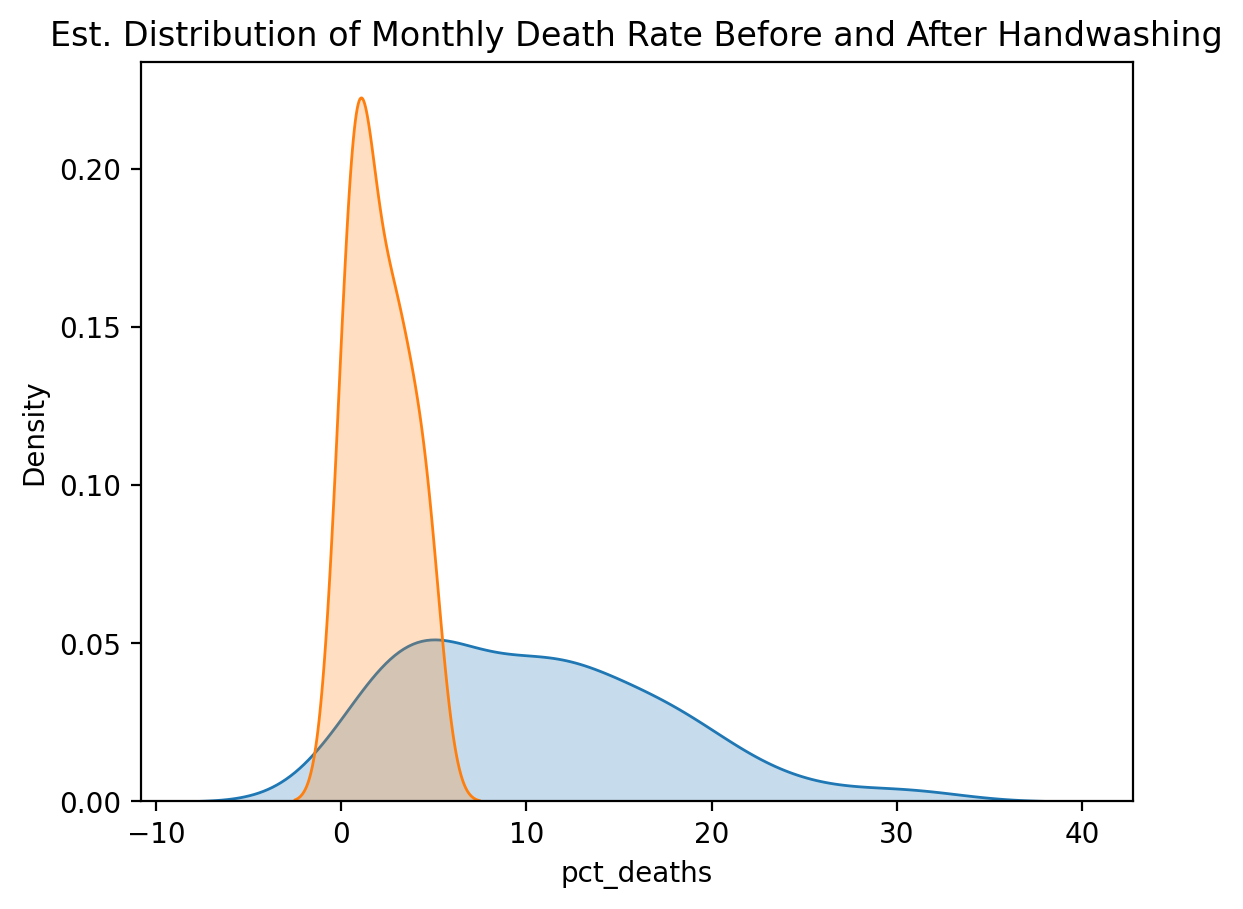

In [42]:
plt.figure(dpi=200)
# By default the distribution estimate includes a negative death rate!
sns.kdeplot(before_washing.pct_deaths, fill=True)
sns.kdeplot(after_washing.pct_deaths, fill=True)
plt.title('Est. Distribution of Monthly Death Rate Before and After Handwashing')
plt.show()

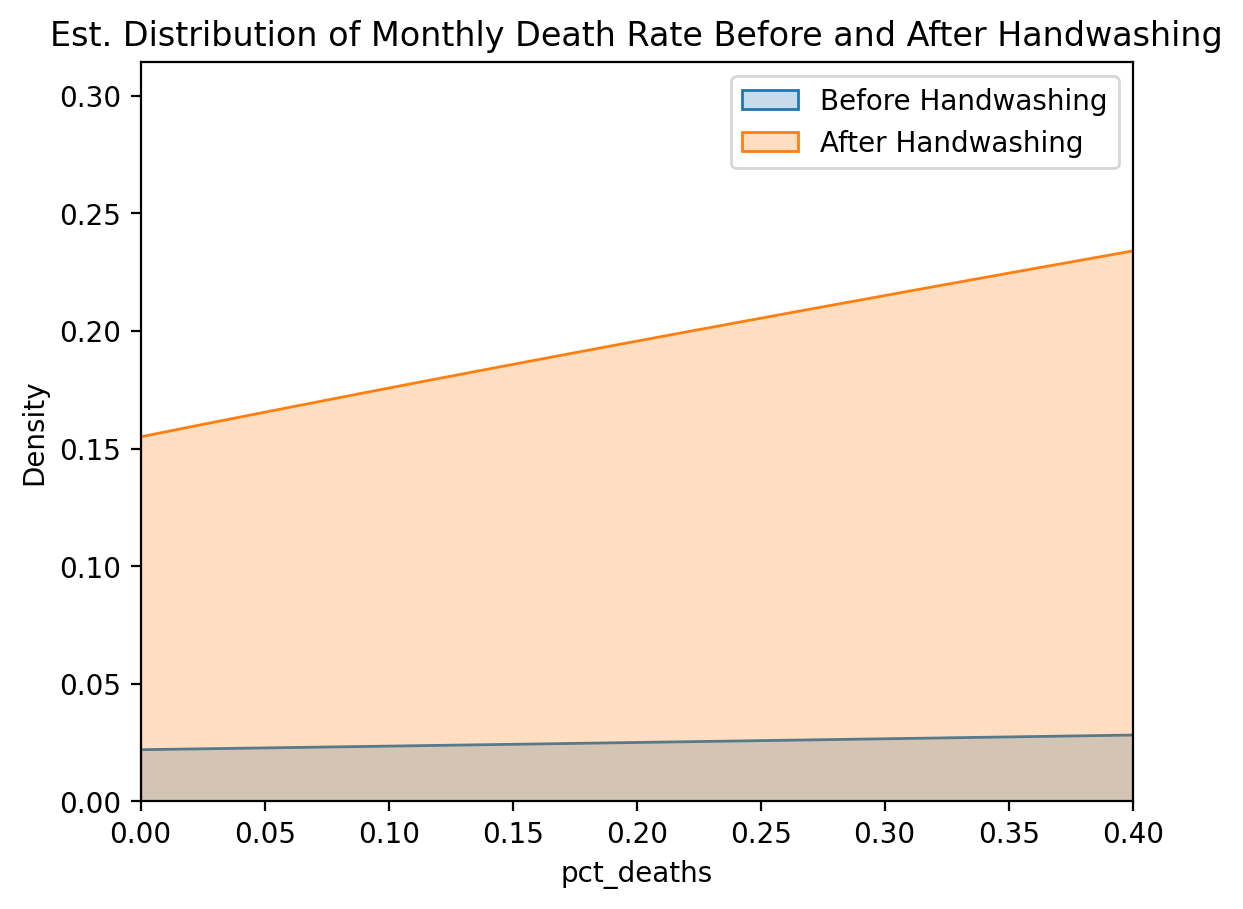

In [41]:
# FAILED TO WORK #

plt.figure(dpi=200)

sns.kdeplot(before_washing.pct_deaths,
            fill=True,
            clip=(0, 1),
            bw_adjust=0.5,
            label='Before Handwashing')

sns.kdeplot(after_washing.pct_deaths,
            fill=True,
            clip=(0, 1),
            bw_adjust=0.5,
            label='After Handwashing')

plt.title('Est. Distribution of Monthly Death Rate Before and After Handwashing')
plt.xlim(0, 0.40) # Set x-axis limits from 0 to 40%

plt.legend() # Display the legend
plt.show()

### Use a T-Test to Show Statistical Significance

**Challenge**: Use a t-test to determine if the differences in the means are statistically significant or purely due to chance.

If the p-value is less than 1% then we can be 99% certain that handwashing has made a difference to the average monthly death rate.

* Import `stats` from scipy
* Use the [`.ttest_ind()` function](https://docs.scipy.org/]doc/scipy/reference/generated/scipy.stats.ttest_ind.html) to calculate the t-statistic and the p-value
* Is the difference in the average proportion of monthly deaths statistically significant at the 99% level?



In [39]:
# Use a t-test to determine if the differences in the means are statistically significant or purely due to chance.
# When we calculate the p_value we see that it is .00002985%
# This is far below even 1%.

# In other words, the difference in means is highly statistically significant
# and we can go ahead on publish our research paper


import scipy.stats as stats

t_stat, p_value = stats.ttest_ind(a=before_washing.pct_deaths,
                                  b=after_washing.pct_deaths)
print(f'p-palue is {p_value:.10f}')
print(f't-statstic is {t_stat:.4}')

p-palue is 0.0000005157
t-statstic is 5.388


What do you conclude from your analysis, Doctor? 😊

<img src=https://i.imgur.com/rvjNVzQ.gif>